In [78]:
#importing required lib's
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [79]:
#loading the dataset into pandas dataframe
df = pd.read_csv("Banknote_Authentication.csv")

In [80]:
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [81]:
df.tail()

,variance,skewness,curtosis,entropy,class
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1
1371,-2.54190,-0.65804,2.6842,1.19520,1


In [82]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [84]:
#print all available features
df.columns

Index(['variance', 'skewness', 'curtosis', 'entropy', 'class'], dtype='object')

In [85]:
#check for nulls
df.columns[df.isnull().any()]

Index([], dtype='object')

In [86]:
df.shape

(1372, 5)

In [87]:
#count no. of malignants and benigns in the dataset
df['class'].value_counts()

class
0    762
1    610
Name: count, dtype: int64

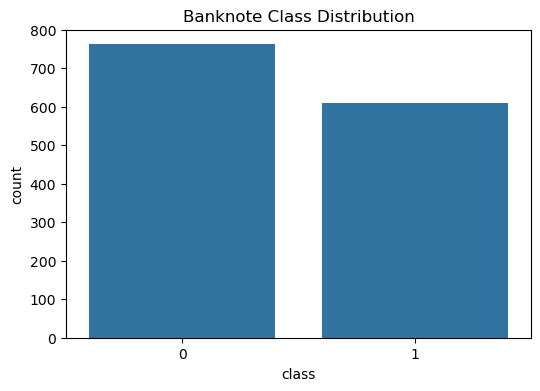

In [88]:
#class distribution graph
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df)
plt.title("Banknote Class Distribution")
plt.show()

In [33]:
df.sample(n=5, random_state=55).sort_values(['variance'])

,variance,skewness,curtosis,entropy,class
1180,-2.21830,-1.2540,2.9986,0.36378,1
769,-0.89409,3.1991,-1.8219,-2.94520,1
1353,0.11592,3.2219,-3.4302,-2.84570,1
239,2.39520,9.5083,-3.1783,-3.00860,0
722,4.84510,8.1116,-2.9512,-1.47240,0


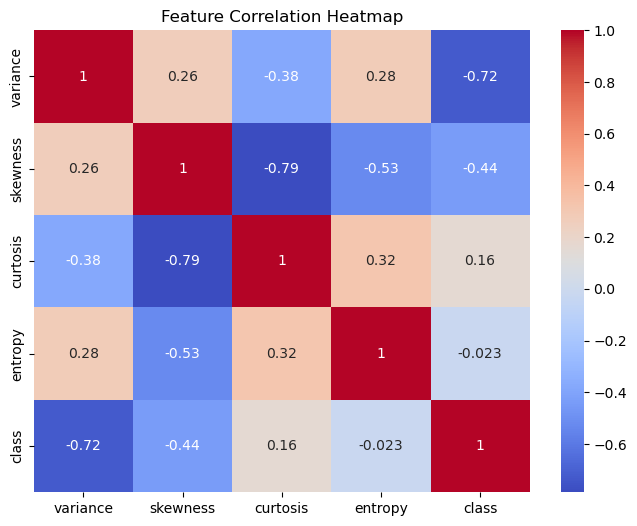

In [89]:
#correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [34]:
#building the model using random forest
#load the features to a variable X
#X is created by simple dropping the diagnosis column and retaining all others

X = df.drop('class', axis = 1)

In [35]:
# load the target variable to y
y = df['class']

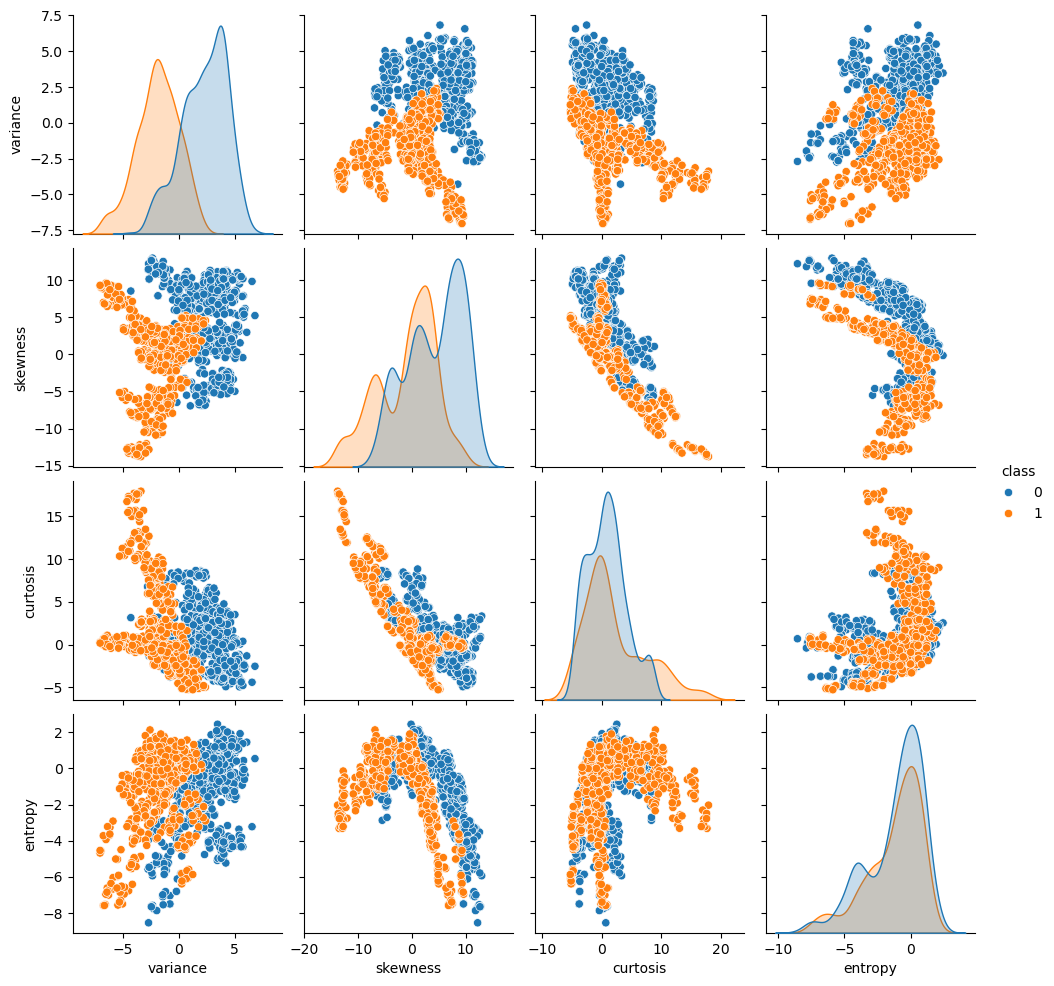

In [90]:
#pairplot-feature relationship
sns.pairplot(df, hue='class')
plt.show()

In [91]:
#feature and target split
X = df.drop('class', axis=1)
y = df['class']

In [96]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [97]:
#Let's create an instance for the LogisticRegression model and then train it with the training set.
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [98]:
y_pred = rf.predict(X_test)

In [53]:
#Evaluate the Model.
#Evaluation is done both on the training and test dataset to check for overfitting
#Getting predictions from the model 
y_test_hat = Classifier.predict(X_test)

#Compare the predicted values with the actuals.
Results = pd.DataFrame({'Actual': y_test}) 
column = pd.DataFrame({'Predictions': y_test_hat})
Results = Results.join(column.set_index(Results.index))
Results.head(5)

,Actual,Predictions
1240,1,1
703,0,0
821,1,1
1081,1,1
37,0,0


In [54]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_test_hat))

0.9878640776699029


In [58]:
#Get the predictions from the model for the training set.
y_train_hat = Classifier.predict(X_train)
print(accuracy_score(y_train, y_train_hat))

0.9885416666666667


In [63]:
# the Confusion Matrix.
from sklearn.metrics import confusion_matrix, recall_score, precision_score

cm = confusion_matrix(y_test, y_test_hat)
print(cm)

[[231   4]
 [  1 176]]


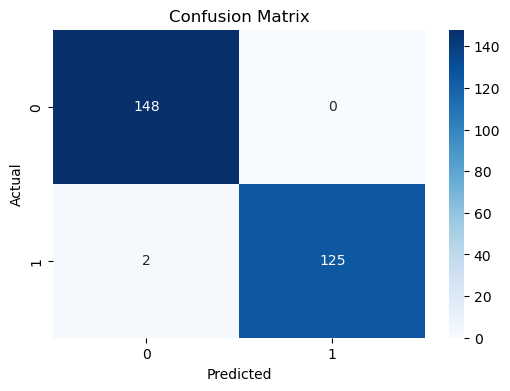

In [106]:
#confusion matrix graph
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [65]:
#Assigning Variables for convinience
TN = cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

recall = TP/float(FN+TP)
print("recall:", recall)

precision = TP/float(TP+FP)
print("precision:", precision)

specificity = TN/(TN+FP)
print("specificity:", specificity)

recall: 0.9943502824858758
precision: 0.9777777777777777
specificity: 0.9829787234042553


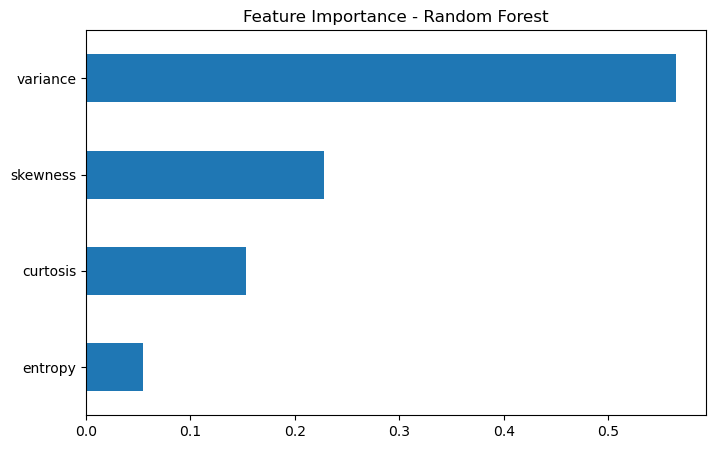

In [101]:
importance = rf.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance - Random Forest")
plt.show()

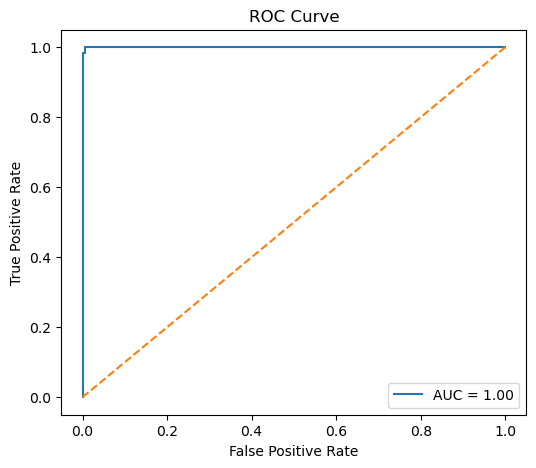

In [102]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

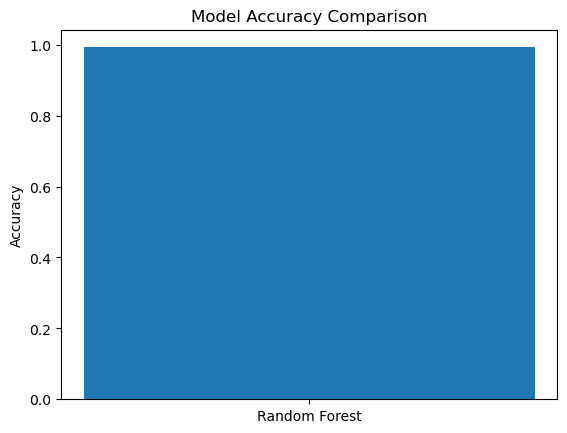

In [103]:
models = ['Random Forest']
accuracies = [accuracy_score(y_test, y_pred)]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [107]:
#accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9927272727272727
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       148
           1       1.00      0.98      0.99       127

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275

